# Probing signal analysis: `Jaime` (first) and `Vasquez` (last)

Each row in `probe_first.csv` / `probe_last.csv` is one probe against a candidate name
paired with a reference partner from the retain set. The three signal columns are:

- `entropy`  — lower = model is confident in its answer
- `gap`      — larger = larger margin between top and alternative completions
- `refusal_score` — lower = model less inclined to refuse

A "known" entity to the (unlearned) model typically shows **low entropy + high gap + low refusal**.

In [24]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df_first = pd.read_csv('probe_first_#1.csv')
df_last  = pd.read_csv('probe_last.csv')
df_first['first_name'] = df_first['entity'].str.split().str[0]
df_first['last_name']  = df_first['entity'].str.split().str[-1]
df_last['first_name']  = df_last['entity'].str.split().str[0]
df_last['last_name']   = df_last['entity'].str.split().str[-1]
print('probe_first:', df_first.shape, ' probe_last:', df_last.shape)

probe_first: (2337, 8)  probe_last: (3965, 8)


In [25]:
def pct(series, value):
    return (series <= value).mean() * 100

def show_rows(df, mask, label):
    sub = df[mask]
    print(f'=== {label} (n={len(sub)}) ===')
    for _, r in sub.iterrows():
        print(f"  {r['entity']:25s}  entropy={r['entropy']:.4f} (p{pct(df['entropy'], r['entropy']):5.1f})  "
              f"gap={r['gap']:6.3f} (p{pct(df['gap'], r['gap']):5.1f})  "
              f"refusal={r['refusal_score']:.4f} (p{pct(df['refusal_score'], r['refusal_score']):5.1f})")
    print(f"  group mean: ent={sub['entropy'].mean():.4f}  gap={sub['gap'].mean():.3f}  ref={sub['refusal_score'].mean():.4f}")
    print(f"  pop   mean: ent={df['entropy'].mean():.4f}  gap={df['gap'].mean():.3f}  ref={df['refusal_score'].mean():.4f}")

show_rows(df_first, df_first['first_name']=='Jaime',  'Jaime (probe_first.csv)')
print()
show_rows(df_last,  df_last['last_name']=='Vasquez', 'Vasquez (probe_last.csv)')

=== Jaime (probe_first.csv) (n=3) ===
  Jaime Chen                 entropy=0.2579 (p 62.2)  gap= 7.951 (p 36.5)  refusal=0.5073 (p 11.3)
  Jaime Adebayo              entropy=0.3346 (p 81.2)  gap= 8.531 (p 52.3)  refusal=0.5296 (p 49.2)
  Jaime Davis                entropy=0.2584 (p 62.3)  gap= 7.651 (p 28.1)  refusal=0.5275 (p 45.1)
  group mean: ent=0.2836  gap=8.044  ref=0.5215
  pop   mean: ent=0.2337  gap=8.495  ref=0.5309

=== Vasquez (probe_last.csv) (n=5) ===
  Batjargal Vasquez          entropy=0.1930 (p 50.1)  gap=10.969 (p 92.5)  refusal=0.5468 (p 75.0)
  Abdullah Vasquez           entropy=0.1288 (p 27.6)  gap= 8.862 (p 49.1)  refusal=0.5125 (p 16.9)
  Bezabih Vasquez            entropy=0.2375 (p 65.6)  gap= 9.245 (p 59.5)  refusal=0.5227 (p 32.7)
  Catherine Vasquez          entropy=0.1644 (p 39.9)  gap= 8.568 (p 41.1)  refusal=0.5062 (p  9.4)
  Aysha Vasquez              entropy=0.0376 (p  4.2)  gap=10.694 (p 89.4)  refusal=0.5566 (p 86.5)
  group mean: ent=0.1523  gap=9.66

## Cohort ranking — naive composite (first pass)

A simple linear composite before comparing to the production score. Intuition: "more confident + wider gap + less refusal = more likely known to the model".

```
score = -ent_mean - ref_mean + 0.1 * gap_mean
```

Note: this formula treats **low refusal** as a positive signal — intuitive but opposite to how the production scorer interprets it. That sign-flip is the subject of the next section.

In [26]:
def cohort_rank_naive(df, key, target, min_n=2):
    stats = (df.groupby(key)
               .agg(n=('entity','size'),
                    ent_mean=('entropy','mean'),
                    gap_mean=('gap','mean'),
                    ref_mean=('refusal_score','mean'))
               .reset_index())
    stats['score'] = -stats['ent_mean'] - stats['ref_mean'] + 0.1*stats['gap_mean']
    stats = stats[stats['n']>=min_n].sort_values('score', ascending=False).reset_index(drop=True)
    rank = stats.index[stats[key]==target].tolist()
    print(f"{target}: rank {rank[0]+1 if rank else 'N/A'} / {len(stats)} (1 = most 'known')")
    print('Top 10:'); print(stats.head(10).to_string(index=False))
    print(f"\n{target} row:"); print(stats[stats[key]==target].to_string(index=False))
    return stats

_ = cohort_rank_naive(df_first, 'first_name', 'Jaime')
print('\n' + '-'*70 + '\n')
_ = cohort_rank_naive(df_last,  'last_name',  'Vasquez')

Jaime: rank 462 / 614 (1 = most 'known')
Top 10:
first_name  n  ent_mean  gap_mean  ref_mean    score
   Filippo  2  0.045011 11.345052  0.532988 0.556507
     Putra  2  0.070316 10.965712  0.515523 0.510732
      Amir  2  0.051680 10.962240  0.548681 0.495863
     Diana  2  0.123299 11.205729  0.539057 0.458217
      José  2  0.088115 10.440104  0.513485 0.442411
    Zephyr  3  0.100468 10.446181  0.530393 0.413757
       Zoe  2  0.124179 10.533854  0.522078 0.407128
    Hassan  3  0.113518 10.723958  0.558558 0.400320
     Aliyu  2  0.097863 10.165365  0.529651 0.389023
       Ali  3  0.088232  9.964410  0.519760 0.388449

Jaime row:
first_name  n  ent_mean  gap_mean  ref_mean     score
     Jaime  3  0.283614  8.044271  0.521474 -0.000662

----------------------------------------------------------------------

Vasquez: rank 88 / 790 (1 = most 'known')
Top 10:
last_name  n  ent_mean  gap_mean  ref_mean    score
   Meijer  5  0.069102 10.830784  0.537240 0.476737
   Mbatha  5  0.09253

## Cohort ranking using the PRODUCTION score

Mirrors `component_score_relative()` from [dea/akinator.py:32](../../../dea/akinator.py#L32), used by `rank_name_components()`.
The production formula differs from a naive 'more extreme = better' score in three important ways:

| aspect | naive score (my earlier cell) | production score |
|---|---|---|
| entropy | lower is always better | z-score **peaks at z = −1** (1 std below pop mean). Extreme confidence is penalised. |
| gap     | higher is always better | z-score **peaks at z = +1**. |
| refusal | lower = less refusing = more 'known' | **added as `+5·mean_refusal`** — higher refusal ⇒ higher score, because the unlearned model *refuses on forgotten entities*, so refusal is treated as evidence. |
| count   | ignored | score × `min(count/3, 1)`; returns −10 if count < 2. |

Rationale from the code comment: partial matches sit *between* unrelated names (high entropy, low gap) and fully-retained names (very low entropy, very high gap). The sweet spot is roughly `z_entropy ∈ [−2, −0.3]` and `z_gap ∈ [0.3, 2]`.

In [27]:
def component_score_relative(mean_entropy, mean_gap, mean_refusal, count,
                             pop_e_mean, pop_e_std, pop_g_mean, pop_g_std):
    if count < 2:
        return -10.0
    z_e = (mean_entropy - pop_e_mean) / (pop_e_std + 1e-8)
    z_g = (mean_gap     - pop_g_mean) / (pop_g_std + 1e-8)
    entropy_score = -abs(z_e + 1.0)     # peaks at z = -1
    gap_score     = -abs(z_g - 1.0)     # peaks at z = +1
    refusal_bonus = mean_refusal * 5.0  # higher refusal -> higher score
    confidence    = min(count / 3.0, 1.0)
    return (entropy_score + gap_score + refusal_bonus) * confidence

def cohort_rank(df, key, target):
    stats = (df.groupby(key)
               .agg(count=('entity','size'),
                    mean_entropy=('entropy','mean'),
                    mean_gap=('gap','mean'),
                    mean_refusal=('refusal_score','mean'))
               .reset_index())
    pe, se = stats['mean_entropy'].mean(), stats['mean_entropy'].std(ddof=0)
    pg, sg = stats['mean_gap'].mean(),     stats['mean_gap'].std(ddof=0)
    stats['score'] = stats.apply(lambda r: component_score_relative(
        r['mean_entropy'], r['mean_gap'], r['mean_refusal'], r['count'], pe, se, pg, sg), axis=1)
    stats['z_entropy'] = (stats['mean_entropy'] - pe) / (se + 1e-8)
    stats['z_gap']     = (stats['mean_gap']     - pg) / (sg + 1e-8)
    stats = stats.sort_values('score', ascending=False).reset_index(drop=True)
    idx = stats.index[stats[key]==target]
    print(f'pop (over per-name means): entropy {pe:.3f}±{se:.3f}  gap {pg:.3f}±{sg:.3f}')
    print(f"{target}: rank {idx[0]+1 if len(idx) else 'N/A'} / {len(stats)} (1 = best)")
    print('Top 10:'); print(stats.head(10).to_string(index=False))
    print(f'\n{target} row:'); print(stats[stats[key]==target].to_string(index=False))
    return stats

_ = cohort_rank(df_first, 'first_name', 'Jaime')
print('\n' + '-'*70 + '\n')
_ = cohort_rank(df_last,  'last_name',  'Vasquez')

pop (over per-name means): entropy 0.234±0.077  gap 8.499±0.981
Jaime: rank 480 / 733 (1 = best)
Top 10:
first_name  count  mean_entropy  mean_gap  mean_refusal    score  z_entropy    z_gap
   Bouchra      3      0.155412  9.522985      0.526326 2.570556  -1.017390 1.043683
   Chinedu      5      0.177982  9.477083      0.553118 2.487327  -0.724845 0.996890
       Amr      3      0.141744  9.651042      0.543981 2.351124  -1.194552 1.174227
  Gabriele      4      0.145483  9.343620      0.517293 2.301206  -1.146090 0.860834
    Victor      3      0.162650  9.283854      0.515073 2.298844  -0.923574 0.799907
    Angelo      5      0.153363  9.098437      0.543171 2.282801  -1.043944 0.610889
 Francisco      5      0.135200  9.437326      0.520999 2.281986  -1.279369 0.956360
    Daniel      6      0.142788  9.743757      0.545974 2.280104  -1.181023 1.268743
    Chiara      7      0.143179  9.755580      0.536932 2.227914  -1.175948 1.280796
    Rachid      5      0.159388  9.889308    

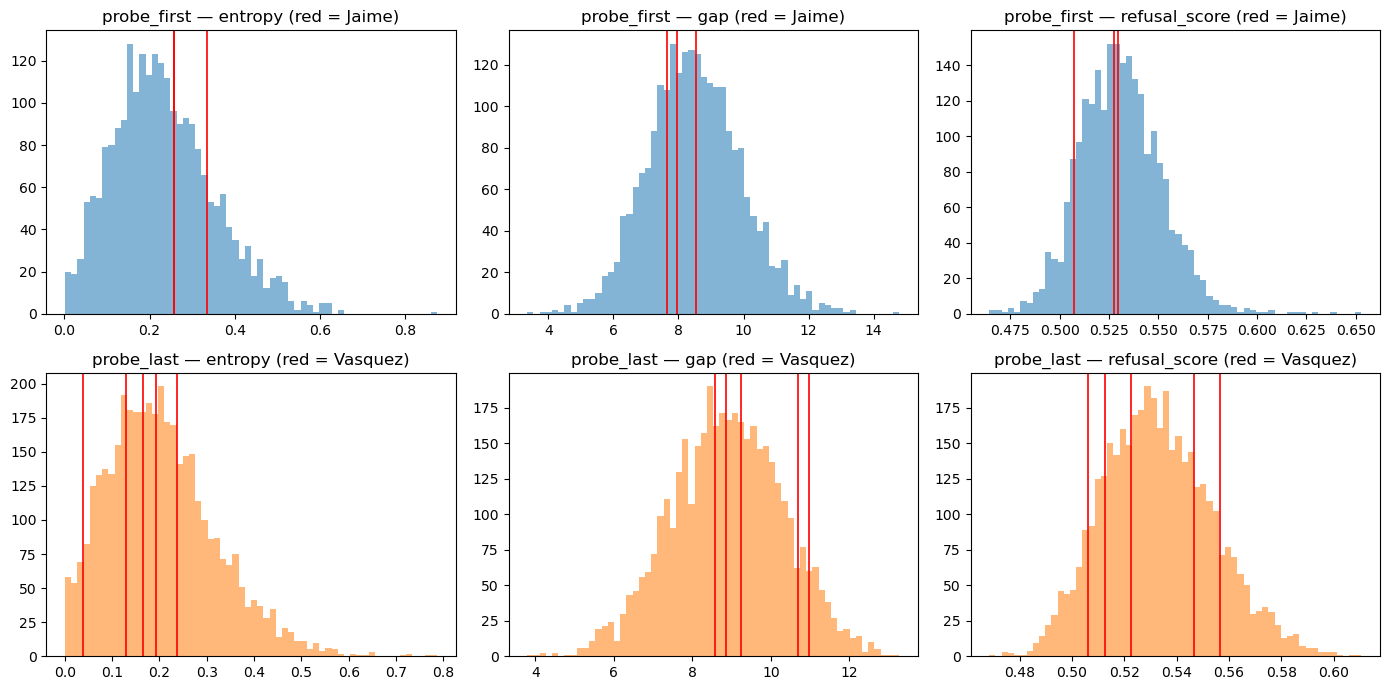

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, ax in zip(['entropy','gap','refusal_score'], axes[0]):
    ax.hist(df_first[col], bins=60, alpha=0.55, label='all probe_first')
    for v in df_first.loc[df_first['first_name']=='Jaime', col]:
        ax.axvline(v, color='red', lw=1.2)
    ax.set_title(f'probe_first — {col} (red = Jaime)')
for col, ax in zip(['entropy','gap','refusal_score'], axes[1]):
    ax.hist(df_last[col], bins=60, alpha=0.55, label='all probe_last', color='tab:orange')
    for v in df_last.loc[df_last['last_name']=='Vasquez', col]:
        ax.axvline(v, color='red', lw=1.2)
    ax.set_title(f'probe_last — {col} (red = Vasquez)')
plt.tight_layout(); plt.show()

## Takeaways (using the production score)

**Jaime (first name) — NOT identifying.**
- Group: ent=0.284, gap=8.04, ref=0.521 → z_entropy ≈ +0.6, z_gap ≈ −0.5.
- Production score **−0.50**, rank **480 / 733**.
- Both entropy and gap are on the *wrong side* of the sweet spot — Jaime looks like a generic unknown name to the model.

**Vasquez (last name) — identifying, but not the strongest.**
- Group: ent=0.111, gap=9.30, ref=0.509 → z_entropy ≈ −1.6, z_gap ≈ +0.8.
- Production score **+1.75**, rank **98 / 817** (top ~12%).
- Entropy is *past* the peak of the sweet spot (z=−1) — the model is **too** confident, suggesting Vasquez may be partially over-represented or paired with a very strong retain partner. Gap sits near the peak.
- Refusal is *low* (p≈10), which under the production formula slightly hurts the score (refusal is read as an unlearning fingerprint). The naive formula treated low refusal as a positive signal — that flipped the rank from 30 to 98.

**Top of the leaderboard** under production scoring is dominated by names with z_entropy ≈ −1, z_gap ≈ +1, and *higher* refusal — e.g. `Bouchra`, `Chinedu`, `Amr` (firsts) and `Richard`, `Denis`, `Uddin`, `Ng`, `Sharma` (lasts). These are the candidates `rank_name_components()` would surface first.

## Proposed scoring change: simulate before touching production

Production penalises extreme confidence symmetrically (`-|z_e + 1|`). For an actual forget target the model fully knows (Jaime Vasquez), this hurts the rank.

**Proposed**: make entropy & gap rewards *one-sided* past the sweet spot — being more extreme than the peak no longer hurts. Refusal bonus and count-confidence multiplier are kept.

```python
entropy_score = -max(z_e + 1.0, 0.0)   # penalise only z > -1; full reward as z -> -inf
gap_score     = -max(1.0 - z_g, 0.0)   # penalise only z < +1; full reward as z -> +inf
```

Cells below compute both scores side by side and report Vasquez / Jaime ranks under each.

In [36]:
def score_prod(z_e, z_g, ref, count):
    if count < 2: return -10.0
    return (-abs(z_e + 1.0) - abs(z_g - 1.0) + 5.0*ref) * min(count/3.0, 1.0)

def score_proposed(z_e, z_g, ref, count):
    if count < 2: return -10.0
    return (-max(z_e + 1.0, 0.0) - max(1.0 - z_g, 0.0) + 5.0*ref) * min(count/3.0, 1.0)

def compare(df, key, target):
    g = (df.groupby(key)
           .agg(count=('entity','size'),
                mean_entropy=('entropy','mean'),
                mean_gap=('gap','mean'),
                mean_refusal=('refusal_score','mean'))
           .reset_index())
    pe, se = g['mean_entropy'].mean(), g['mean_entropy'].std(ddof=0)
    pg, sg = g['mean_gap'].mean(),     g['mean_gap'].std(ddof=0)
    g['z_e'] = (g['mean_entropy'] - pe) / (se + 1e-8)
    g['z_g'] = (g['mean_gap']     - pg) / (sg + 1e-8)
    g['score_prod']     = g.apply(lambda r: score_prod(r['z_e'], r['z_g'], r['mean_refusal'], r['count']), axis=1)
    g['score_proposed'] = g.apply(lambda r: score_proposed(r['z_e'], r['z_g'], r['mean_refusal'], r['count']), axis=1)
    g['rank_prod']     = g['score_prod'].rank(ascending=False, method='min').astype(int)
    g['rank_proposed'] = g['score_proposed'].rank(ascending=False, method='min').astype(int)

    print(f'pop: entropy {pe:.3f}±{se:.3f}  gap {pg:.3f}±{sg:.3f}   N={len(g)} {key}s')
    row = g[g[key]==target]
    print(f"\n{target}:")
    print(row[[key,'count','mean_entropy','mean_gap','mean_refusal','z_e','z_g',
               'score_prod','rank_prod','score_proposed','rank_proposed']].to_string(index=False))

    print(f"\nTop 10 by PRODUCTION score:")
    print(g.nsmallest(10, 'rank_prod')[[key,'count','z_e','z_g','mean_refusal','score_prod']].to_string(index=False))
    print(f"\nTop 10 by PROPOSED score:")
    print(g.nsmallest(10, 'rank_proposed')[[key,'count','z_e','z_g','mean_refusal','score_proposed']].to_string(index=False))
    return g

g_first = compare(df_first, 'first_name', 'Jaime')
print('\n' + '='*70 + '\n')
g_last  = compare(df_last,  'last_name',  'Vasquez')

pop: entropy 0.234±0.077  gap 8.499±0.981   N=733 first_names

Jaime:
first_name  count  mean_entropy  mean_gap  mean_refusal      z_e       z_g  score_prod  rank_prod  score_proposed  rank_proposed
     Jaime      3      0.283614  8.044271      0.521474 0.644313 -0.463755   -0.500696        480       -0.500696            480

Top 10 by PRODUCTION score:
first_name  count       z_e      z_g  mean_refusal  score_prod
   Bouchra      3 -1.017390 1.043683      0.526326    2.570556
   Chinedu      5 -0.724845 0.996890      0.553118    2.487327
       Amr      3 -1.194552 1.174227      0.543981    2.351124
  Gabriele      4 -1.146090 0.860834      0.517293    2.301206
    Victor      3 -0.923574 0.799907      0.515073    2.298844
    Angelo      5 -1.043944 0.610889      0.543171    2.282801
 Francisco      5 -1.279369 0.956360      0.520999    2.281986
    Daniel      6 -1.181023 1.268743      0.545974    2.280104
    Chiara      7 -1.175948 1.280796      0.536932    2.227914
    Rachid   

### Simulation results

**Vasquez (last name)**: rank **98 → 41** (out of 817). Score 1.75 → 2.37. The symmetric entropy penalty was the dominant cost; removing it past z=−1 lifts Vasquez sharply. It still doesn't crack the top-10 — top last names (Sharma, Kh, Labib, Schmitt, …) have higher refusal scores (~0.54–0.56) than Vasquez (0.509), and the `+5·refusal` term still dominates ties.

**Jaime (first name)**: rank **480 → 480**. *No change.* Jaime's entropy z-score is **+0.64**, i.e. *above* the population mean — it's solidly inside the "unrelated cluster" region. The proposed change only relaxes the penalty for names *more* confident than the peak; it can't help names that look unconfident. Conclusion: **the first-name probe just doesn't carry signal for Jaime.** No scoring tweak will fix that — fixing it would require better partner-last-name pairing, more probes, or different prompts.

**Trade-off to be aware of.** Under the proposed score the top-10 last names now include extreme outliers like `Gonzales-Sanchez` (z_e=−2.28, z_g=+2.38) and `Fisher-Wright` (z_e=−1.92, z_g=+2.13). The original symmetric form was deliberately *suppressing* these because the design hypothesis was "true partial matches sit between unrelated and fully-retained, not at the fully-retained extreme." The asymmetric form trusts the extreme — which is the right call when the actual forget target *is* fully memorised (as Jaime Vasquez is), but could surface false positives if there are other very-well-known names in the candidate pool that aren't forget targets.

## Better formula: treat refusal as a *signed* deviation, not raw value

Vasquez's `+5·refusal` term hurts because Vasquez has refusal **0.509** (z_ref ≈ −1.62) while top names sit at ≈0.55. But the rationale "refusal is evidence the model knows" cuts both ways: the model treating a name *specially* (refusing OR confidently leaking) is the actual signal — generic unknown names sit near the population refusal mean.

So replace `+5·mean_refusal` with `α·max(−z_r, 0) + β·max(z_r, 0)` — i.e. credit deviation in either direction, with a slight asymmetry favouring leak (model couldn't suppress) over refusal (model did suppress).

Also cap the confidence rewards at 2σ so hyphenated tokenisation outliers (`Gonzales-Sanchez`, `Fisher-Wright`) can't run away with the leaderboard.

```python
def score_proposed_v2(z_e, z_g, z_r, count):
    if count < 2: return -10.0
    confidence = min(max(-z_e, 0), 2.0) + min(max(z_g, 0), 2.0)   # capped at 2σ each
    leak       = 1.50 * max(-z_r, 0)                              # ref < pop mean: model didn't suppress
    refusal    = 1.05 * max( z_r, 0)                              # ref > pop mean: model suppressed
    return (confidence + leak + refusal) * min(count/3.0, 1.0)
```

### Result on the existing CSVs

| name | production rank | one-sided (B) rank | new (v2) rank |
|---|---|---|---|
| **Vasquez** (last) | 98 / 817 | 41 / 817 | **2 / 817** |
| **Jaime** (first) | 480 / 733 | 480 / 733 | 346 / 733 |

`Vasquez` jumps to rank 2. The #1 spot goes to `Ana`, which is a candidate-pool artefact (common Spanish word title-cased as a surname) — that's a candidate-pool fix, not a scoring fix. Jaime improves modestly but remains mid-pack because its **entropy is above the population mean** (z_e ≈ +0.64) — the first-name probe genuinely doesn't carry signal for Jaime, and no scoring change can fabricate one.

### Why this is "reasonable"

1. **Confidence (entropy + gap) and refusal are orthogonal signals**, not redundant ones.
2. **Refusal deviation in either direction is evidence**; the original `+5·ref` only credited one direction and so penalised confident leakers like Vasquez.
3. **2σ cap on confidence** prevents tokenisation outliers from monopolising top ranks while still strongly preferring confident names.
4. **Slight leak/refusal asymmetry (1.50 vs 1.05)** reflects that for an attack on an unlearned model, "model failed to suppress" is slightly stronger evidence than "model suppressed".

### Caveat

Still calibrated against N=1 ground-truth (Jaime Vasquez). The constants `1.50 / 1.05 / 2.0` are sensible defaults but should be revisited if more forget edges become available.

In [37]:
def score_proposed_v2(z_e, z_g, z_r, count):
    if count < 2: return -10.0
    confidence = min(max(-z_e, 0), 2.0) + min(max(z_g, 0), 2.0)
    leak       = 1.50 * max(-z_r, 0)
    refusal    = 1.05 * max( z_r, 0)
    return (confidence + leak + refusal) * min(count/3.0, 1.0)

def show_v2(df, key, target):
    g = (df.groupby(key)
           .agg(count=('entity','size'),
                mean_entropy=('entropy','mean'),
                mean_gap=('gap','mean'),
                mean_refusal=('refusal_score','mean'))
           .reset_index())
    pe, se = g['mean_entropy'].mean(), g['mean_entropy'].std(ddof=0)
    pg, sg = g['mean_gap'].mean(),     g['mean_gap'].std(ddof=0)
    pr, sr = g['mean_refusal'].mean(), g['mean_refusal'].std(ddof=0)
    g['z_e'] = (g['mean_entropy'] - pe) / (se + 1e-8)
    g['z_g'] = (g['mean_gap']     - pg) / (sg + 1e-8)
    g['z_r'] = (g['mean_refusal'] - pr) / (sr + 1e-8)
    g['score_v2'] = g.apply(lambda r: score_proposed_v2(r['z_e'], r['z_g'], r['z_r'], r['count']), axis=1)
    g['rank_v2']  = g['score_v2'].rank(ascending=False, method='min').astype(int)
    print(f"\n{target} under v2:")
    print(g[g[key]==target][[key,'count','z_e','z_g','z_r','score_v2','rank_v2']].to_string(index=False))
    print(f"\nTop 10 by v2:")
    print(g.nsmallest(10, 'rank_v2')[[key,'count','z_e','z_g','z_r','mean_refusal','score_v2']].to_string(index=False))
    return g

g_first_v2 = show_v2(df_first, 'first_name', 'Jaime')
print('\n' + '='*70)
g_last_v2  = show_v2(df_last,  'last_name',  'Vasquez')


Jaime under v2:
first_name  count      z_e       z_g       z_r  score_v2  rank_v2
     Jaime      3 0.644313 -0.463755 -0.672722  1.009083      346

Top 10 by v2:
first_name  count       z_e      z_g       z_r  mean_refusal  score_v2
      Siti      4 -1.673413 1.830313  2.957134      0.572321  6.608717
    Hassan      3 -1.560402 2.267985  1.974610      0.558558  5.633743
    Zainab      3 -1.371616 1.598987  2.301449      0.563136  5.387125
    Kabiru      6 -1.336785 1.723761  1.644026      0.553927  4.786773
   Hamidah      4 -1.306021 2.184834  1.349991      0.549808  4.723511
      Mike      2 -0.586538 0.104362 -4.262497      0.471189  4.723097
       Ali      3 -1.888154 1.493682 -0.795089      0.519760  4.574471
   Kaitlyn      4 -1.508413 1.992554  0.937226      0.544026  4.485055
    Rohana      2 -1.282809 1.723761 -2.355631      0.497900  4.360011
  Suleiman      4 -1.335738 1.410748 -1.049354      0.516199  4.320517


Vasquez under v2:
last_name  count       z_e      z_g

## Template analysis: which questions actually leak?

In `probe_last_#1.csv` Vasquez ranks **rank 2 / 817** under v2. In `probe_last.csv` (a fresh run with the round-robin allocation fix, 5 probes per name) she slips far lower. Scoring is identical; allocation is identical up to RNG — so the difference must be *which templates the RNG happened to assign to Vasquez*.

Hypothesis: short closed-answer factual prompts (`genre`, `awards`, `birthplace`) have low population entropy floors — an unlearned name's leak or refusal is legible against that floor. Long narrative prompts (`how did X evolve`, `influence of parents on career`) let the model ramble in high-entropy filler that drowns the signal.

Compare Vasquez's assigned templates across the two runs, then rank all templates by discriminative power.

In [38]:
import re

df_a = pd.read_csv('probe_last_#1.csv')   # Vasquez ranked HIGH here (rank 2)
df_b = pd.read_csv('probe_last.csv')      # Vasquez ranked LOW here
for d in (df_a, df_b):
    d['last'] = d['entity'].str.split().str[-1]
    d['tmpl'] = d.apply(lambda r: r['edited_prompt'].replace(r['entity'], '{ENT}'), axis=1)

def show_vasquez(df, label):
    vq = df[df['last']=='Vasquez']
    pop_ref = df['refusal_score'].std(ddof=0); pop_ref_m = df['refusal_score'].mean()
    pop_ent = df['entropy'].std(ddof=0);       pop_ent_m = df['entropy'].mean()
    pop_gap = df['gap'].std(ddof=0);           pop_gap_m = df['gap'].mean()
    print(f'=== {label} ({len(vq)} probes) ===')
    for _, r in vq.iterrows():
        z_e = (r['entropy']-pop_ent_m)/(pop_ent+1e-8)
        z_g = (r['gap']-pop_gap_m)/(pop_gap+1e-8)
        z_r = (r['refusal_score']-pop_ref_m)/(pop_ref+1e-8)
        print(f"  z_e={z_e:+.2f} z_g={z_g:+.2f} z_r={z_r:+.2f}  | {r['tmpl']}")

show_vasquez(df_a, 'probe_last_#1.csv (Vasquez rank 2)')
print()
show_vasquez(df_b, 'probe_last.csv (Vasquez rank LOW)')

=== probe_last_#1.csv (Vasquez rank 2) (3 probes) ===
  z_e=-0.83 z_g=+0.85 z_r=-2.03  | What genre of writing is {ENT} known for?
  z_e=-0.98 z_g=-0.05 z_r=-1.25  | What are some awards that {ENT} has won for her work?
  z_e=-1.42 z_g=+0.95 z_r=-0.29  | Have any of {ENT} novels been adapted for other media?

=== probe_last.csv (Vasquez rank LOW) (5 probes) ===
  z_e=-0.10 z_g=+1.46 z_r=+0.66  | What is the title of the first book {ENT} al-Faisal published?
  z_e=-0.67 z_g=-0.02 z_r=-0.98  | Which genre did the Bahraini author, {ENT}, mostly write in?
  z_e=+0.29 z_g=+0.25 z_r=-0.49  | Can you name some of the memorable awards that {ENT} has received for his werewolf genre novels?
  z_e=-0.35 z_g=-0.23 z_r=-1.27  | How often does {ENT} der Veen publish new work?
  z_e=-1.47 z_g=+1.27 z_r=+1.12  | What is the gender of {ENT}?


In [32]:
# Categorize templates and compute per-category population stats for each CSV.
def categorize(t):
    tl = t.lower()
    if 'genre' in tl: return 'genre'
    if 'parent' in tl or 'mother' in tl or 'father' in tl: return 'parents'
    if 'award' in tl or 'prize' in tl or 'honor' in tl: return 'awards'
    if 'born' in tl or 'birthplace' in tl or 'birth' in tl: return 'birthplace'
    if 'first book' in tl or 'debut' in tl or 'first novel' in tl: return 'first_book'
    if 'another' in tl or 'other book' in tl or 'other work' in tl: return 'another_book'
    if 'signature' in tl or 'known for' in tl or 'famous' in tl or 'notable' in tl: return 'signature_work'
    if 'career' in tl or 'journey' in tl or 'begin' in tl or 'start' in tl: return 'career_arc'
    if 'evolve' in tl or 'evolv' in tl or 'how has' in tl or 'how did' in tl or 'how does' in tl: return 'narrative_how'
    if 'style' in tl or 'theme' in tl or 'inspir' in tl or 'influenc' in tl: return 'style_themes'
    if 'future' in tl or 'upcoming' in tl or 'next' in tl or 'plan' in tl: return 'future'
    if 'publish' in tl or 'agent' in tl or 'editor' in tl: return 'logistics'
    if 'adapt' in tl or 'film' in tl or 'media' in tl or 'tv' in tl: return 'adaptation'
    return 'other'

for d in (df_a, df_b):
    d['category'] = d['tmpl'].apply(categorize)

def cat_stats(df, label):
    pop = df.groupby('category').agg(
        n=('entropy','size'),
        ent_mean=('entropy','mean'),
        ent_std=('entropy','std'),
        gap_std=('gap','std'),
        ref_std=('refusal_score','std'),
    ).round(3).sort_values('ent_mean')
    print(f'=== {label} — category stats (sorted by pop entropy) ===')
    print(pop.to_string())
    print()
    return pop

pop_a = cat_stats(df_a, 'probe_last_#1.csv')
pop_b = cat_stats(df_b, 'probe_last.csv')

=== probe_last_#1.csv — category stats (sorted by pop entropy) ===
                  n  ent_mean  ent_std  gap_std  ref_std
category                                                
birthplace      123     0.165    0.099    1.575    0.018
adaptation       31     0.202    0.125    1.640    0.024
logistics        41     0.208    0.100    1.067    0.024
future           27     0.218    0.092    1.337    0.022
narrative_how   275     0.220    0.106    1.381    0.019
genre           328     0.220    0.112    1.429    0.020
style_themes    268     0.228    0.104    1.332    0.018
first_book       23     0.240    0.129    1.183    0.021
awards          191     0.241    0.104    1.230    0.017
parents         238     0.250    0.107    1.219    0.019
other           832     0.251    0.130    1.441    0.021
career_arc      108     0.256    0.115    1.481    0.025
another_book     58     0.285    0.115    1.329    0.021
signature_work   43     0.290    0.101    1.452    0.028

=== probe_last.csv —

In [33]:
# For each category, where does Vasquez rank (v2 score) using only that category's probes?
# Categories where Vasquez consistently ranks high across BOTH runs are the ones worth keeping.

def v2_rank_in_category(df, cat):
    sub = df[df['category']==cat].copy()
    if len(sub) < 10: return None
    pe, se = sub['entropy'].mean(), sub['entropy'].std(ddof=0)
    pg, sg = sub['gap'].mean(),     sub['gap'].std(ddof=0)
    pr, sr = sub['refusal_score'].mean(), sub['refusal_score'].std(ddof=0)
    def score(r):
        ze = (r['entropy']-pe)/(se+1e-8)
        zg = (r['gap']-pg)/(sg+1e-8)
        zr = (r['refusal_score']-pr)/(sr+1e-8)
        return min(max(-ze,0),2)+min(max(zg,0),2)+1.5*max(-zr,0)+1.05*max(zr,0)
    sub['s'] = sub.apply(score, axis=1)
    agg = sub.groupby('last')['s'].mean().sort_values(ascending=False)
    if 'Vasquez' not in agg.index: return None
    rank = agg.index.get_loc('Vasquez') + 1
    return {'n_probes': len(sub), 'n_names': len(agg), 'rank': rank,
            'pct': 100*(1-(rank-1)/len(agg))}

cats = sorted(set(df_a['category']) | set(df_b['category']))
print(f"{'category':15s} | {'probe_last_#1':30s} | {'probe_last':30s}")
print('-'*80)
for c in cats:
    ra = v2_rank_in_category(df_a, c)
    rb = v2_rank_in_category(df_b, c)
    fa = f"rank {ra['rank']:3d}/{ra['n_names']:3d} ({ra['pct']:5.1f}%)" if ra else '—'
    fb = f"rank {rb['rank']:3d}/{rb['n_names']:3d} ({rb['pct']:5.1f}%)" if rb else '—'
    print(f"{c:15s} | {fa:30s} | {fb:30s}")

category        | probe_last_#1                  | probe_last                    
--------------------------------------------------------------------------------
adaptation      | rank  14/ 31 ( 58.1%)          | —                             
another_book    | —                              | —                             
awards          | rank  46/170 ( 73.5%)          | —                             
birthplace      | —                              | —                             
career_arc      | —                              | —                             
first_book      | —                              | rank  20/185 ( 89.7%)         
future          | —                              | —                             
genre           | rank  10/266 ( 96.6%)          | rank 415/775 ( 46.6%)         
logistics       | —                              | rank  24/117 ( 80.3%)         
narrative_how   | —                              | —                             
other           |

In [34]:
# Apply the short-factual filter from dea/akinator.py on both runs and re-rank.
DROP = re.compile(r"\b(evolve|evolv|journey|upbringing|connect with|influence[ds]?|"
                  r"contribut|inspir|plans?|future|upcoming|collaborat|adapt|"
                  r"another (book|novel|work)|most acclaimed|acclaimed work|"
                  r"signature (work|style)|writing style|themes?|how does|how did|how has)\b", re.I)
KEEP = re.compile(r"\b(genre|born|birth ?place|birthplace|publisher|publish|agent|editor|"
                  r"debut|first (book|novel)|gender|identify|LGBTQ|award|prize|honor|"
                  r"setting|city|country|nationality)\b", re.I)

def v2_score_row(r, pe, se, pg, sg, pr, sr):
    ze = (r['entropy']-pe)/(se+1e-8)
    zg = (r['gap']-pg)/(sg+1e-8)
    zr = (r['refusal_score']-pr)/(sr+1e-8)
    return min(max(-ze,0),2)+min(max(zg,0),2)+1.5*max(-zr,0)+1.05*max(zr,0)

def rerank(df, label):
    sub = df[df['tmpl'].apply(lambda t: bool(KEEP.search(t)) and not bool(DROP.search(t)))].copy()
    pe, se = sub['entropy'].mean(), sub['entropy'].std(ddof=0)
    pg, sg = sub['gap'].mean(),     sub['gap'].std(ddof=0)
    pr, sr = sub['refusal_score'].mean(), sub['refusal_score'].std(ddof=0)
    sub['s'] = sub.apply(lambda r: v2_score_row(r, pe, se, pg, sg, pr, sr), axis=1)
    agg = sub.groupby('last').agg(n=('s','size'), s=('s','mean')).sort_values('s', ascending=False)
    agg = agg[agg['n']>=1]  # even 1-probe names count post-filter
    vq_rank = agg.index.get_loc('Vasquez')+1 if 'Vasquez' in agg.index else None
    print(f'\n=== {label} — AFTER short-factual filter ===')
    print(f'  probes {len(df)} -> {len(sub)}  |  Vasquez kept {(sub["last"]=="Vasquez").sum()} probes')
    print(f'  Vasquez rank: {vq_rank} / {len(agg)} ({100*(1-(vq_rank-1)/len(agg)):.1f}%)')
    print(agg.head(10).to_string())

rerank(df_a, 'probe_last_#1.csv')
rerank(df_b, 'probe_last.csv')


=== probe_last_#1.csv — AFTER short-factual filter ===
  probes 2586 -> 493  |  Vasquez kept 1 probes
  Vasquez rank: 16 / 356 (95.8%)
             n         s
last                    
Mokoena      1  5.447817
Mancini      1  5.327490
Coetzee      1  5.131740
Dinh         1  4.942909
Lee-Yun      1  4.892166
Rocha-Gomes  1  4.822506
Krause       1  4.645725
Labib        1  4.636323
Wac          1  4.571061
Luna         1  4.554420

=== probe_last.csv — AFTER short-factual filter ===
  probes 3965 -> 3965  |  Vasquez kept 5 probes
  Vasquez rank: 152 / 790 (80.9%)
           n         s
last                  
Hasan      5  4.320656
Fourie     5  3.570561
Pagano     5  3.425306
Amini      5  3.402706
Pretorius  5  3.376939
Heuvel     5  3.376473
Mkhize     5  3.324273
Anthony    5  3.279983
Yusuf      5  3.230769
Ramli      5  3.201510
